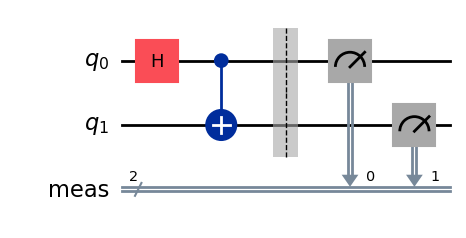

Contagens: {'00': 523, '11': 501}
Probabilidades: {'00': 0.5107421875, '01': 0.0, '10': 0.0, '11': 0.4892578125}


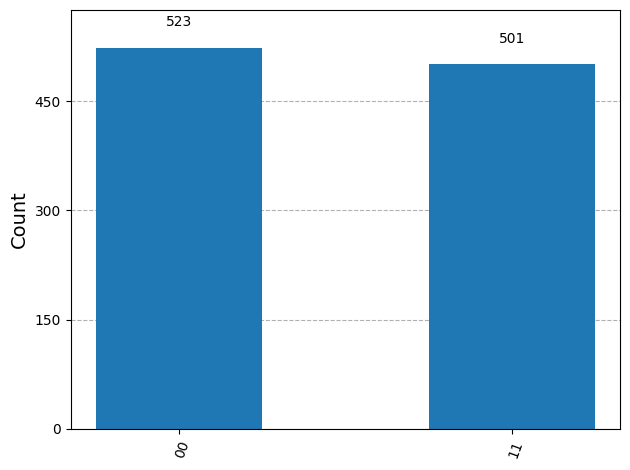

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

# Criação do circuito de Bell
circuit = QuantumCircuit(2)

circuit.h(0)       # Superposição no primeiro qubit
circuit.cx(0, 1)   # Emaranhamento
circuit.measure_all()

# Mostra o circuito
display(circuit.draw("mpl"))

# Execução ideal com 1024 shots
sampler = StatevectorSampler()
result = sampler.run([circuit], shots=1024).result()

counts = result[0].data.meas.get_counts()

print("Contagens:", counts)

# Converte contagens em probabilidades
probabilities = {
    state: counts.get(state, 0) / 1024
    for state in ["00", "01", "10", "11"]
}

print("Probabilidades:", probabilities)

plot_histogram(counts)

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

key = input("Digite sua chave de API do IBM Quantum: ")

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=key,
    overwrite=True
)

qiskit_runtime_service.__init__:WARNING:2026-07-14 10:09:00,054: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: teste. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-14 10:09:00,369: Loading instance: teste, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-14 10:09:03,287: Using instance: teste, plan: open


Máquina selecionada: ibm_marrakesh
Job ID: d9b39sbv6alc73csgqv0
Aguardando resultado...
Contagens na máquina real: {'11': 493, '00': 515, '10': 6, '01': 10}
Probabilidades na máquina real: {'00': 0.5029296875, '01': 0.009765625, '10': 0.005859375, '11': 0.4814453125}


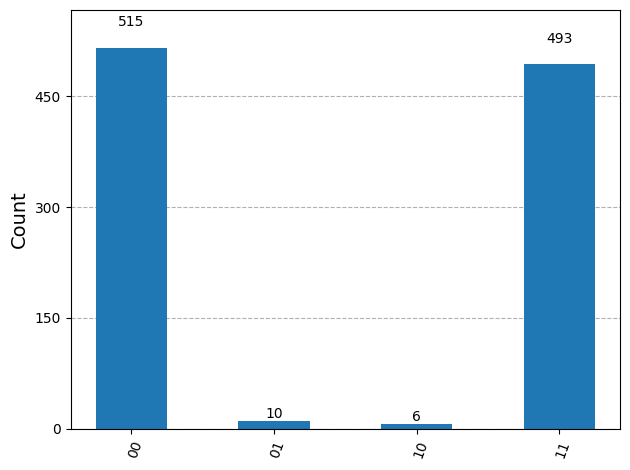

In [3]:
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Circuito de Bell
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()

# Conecta à IBM Quantum
service = QiskitRuntimeService()

# Seleciona uma máquina real operacional
backend = service.least_busy(
    operational=True,
    simulator=False
)

print("Máquina selecionada:", backend.name)

# Adapta o circuito às portas e conexões da máquina
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuit = pass_manager.run(circuit)

# Executa na máquina real
sampler = SamplerV2(mode=backend)
job = sampler.run([isa_circuit], shots=1024)

print("Job ID:", job.job_id())
print("Aguardando resultado...")

result_real = job.result()
counts_real = result_real[0].data.meas.get_counts()

print("Contagens na máquina real:", counts_real)

probabilities_real = {
    state: counts_real.get(state, 0) / 1024
    for state in ["00", "01", "10", "11"]
}

print("Probabilidades na máquina real:", probabilities_real)

plot_histogram(counts_real)

## Ex 2

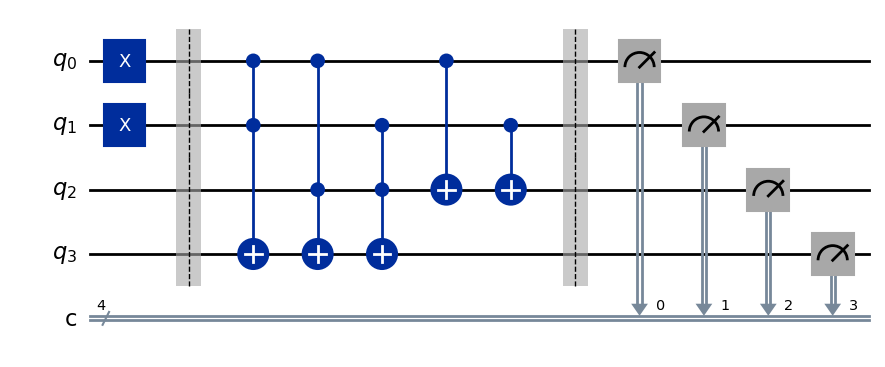

Contagens: {'1011': 1024}
Probabilidades: {'1011': 1.0}


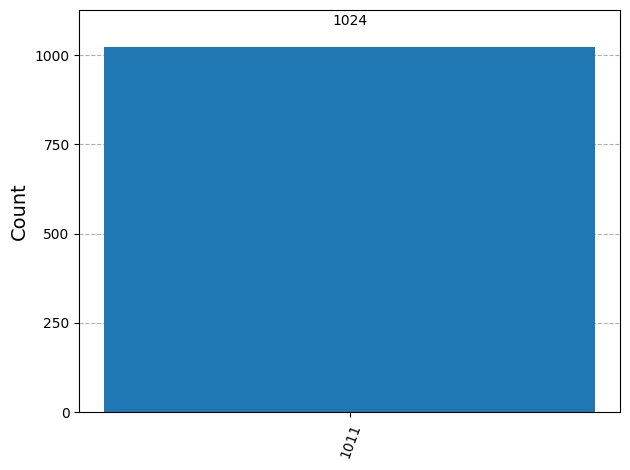

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Valores de entrada
carry_in = 0
B = 1
A = 1

# q[0] = A
# q[1] = B
# q[2] = Carry in, depois armazena S
# q[3] = Carry out
circuit = QuantumCircuit(4, 4)

# Preparação das entradas
if A == 1:
    circuit.x(0)

if B == 1:
    circuit.x(1)

if carry_in == 1:
    circuit.x(2)

circuit.barrier()

# Cálculo do Carry out
circuit.ccx(0, 1, 3)
circuit.ccx(0, 2, 3)
circuit.ccx(1, 2, 3)

# Cálculo da soma S
circuit.cx(0, 2)
circuit.cx(1, 2)

circuit.barrier()

# Mede q0, q1, q2 e q3 nos bits clássicos correspondentes
circuit.measure(range(4), range(4))

display(circuit.draw("mpl"))

# Simulador ideal
simulator = AerSimulator()

compiled_circuit = transpile(circuit, simulator)

result = simulator.run(
    compiled_circuit,
    shots=1024
).result()

counts = result.get_counts()

print("Contagens:", counts)

probabilities = {
    state: count / 1024
    for state, count in counts.items()
}

print("Probabilidades:", probabilities)

plot_histogram(counts)

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()
shots = 1024


def criar_somador(A, B, carry_in):
    circuit = QuantumCircuit(4, 4)

    # Preparação das entradas
    if A == 1:
        circuit.x(0)

    if B == 1:
        circuit.x(1)

    if carry_in == 1:
        circuit.x(2)

    circuit.barrier()

    # Carry out
    circuit.ccx(0, 1, 3)
    circuit.ccx(0, 2, 3)
    circuit.ccx(1, 2, 3)

    # Soma
    circuit.cx(0, 2)
    circuit.cx(1, 2)

    circuit.barrier()
    circuit.measure(range(4), range(4))

    return circuit


for carry_in in [0, 1]:
    for B in [0, 1]:
        for A in [0, 1]:

            circuit = criar_somador(A, B, carry_in)
            compiled = transpile(circuit, simulator)

            result = simulator.run(
                compiled,
                shots=shots
            ).result()

            counts = result.get_counts()

            expected = max(counts, key=counts.get)
            probability = counts[expected] / shots

            print(
                f"Cin={carry_in}, B={B}, A={A} "
                f"-> resultado={expected}, "
                f"probabilidade={probability:.2%}"
            )

Cin=0, B=0, A=0 -> resultado=0000, probabilidade=100.00%
Cin=0, B=0, A=1 -> resultado=0101, probabilidade=100.00%
Cin=0, B=1, A=0 -> resultado=0110, probabilidade=100.00%
Cin=0, B=1, A=1 -> resultado=1011, probabilidade=100.00%
Cin=1, B=0, A=0 -> resultado=0100, probabilidade=100.00%
Cin=1, B=0, A=1 -> resultado=1001, probabilidade=100.00%
Cin=1, B=1, A=0 -> resultado=1010, probabilidade=100.00%
Cin=1, B=1, A=1 -> resultado=1111, probabilidade=100.00%


qiskit_runtime_service.__init__:WARNING:2026-07-14 10:19:35,711: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: teste. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-14 10:19:36,087: Loading instance: teste, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-14 10:19:38,838: Using instance: teste, plan: open


Máquina selecionada: ibm_marrakesh


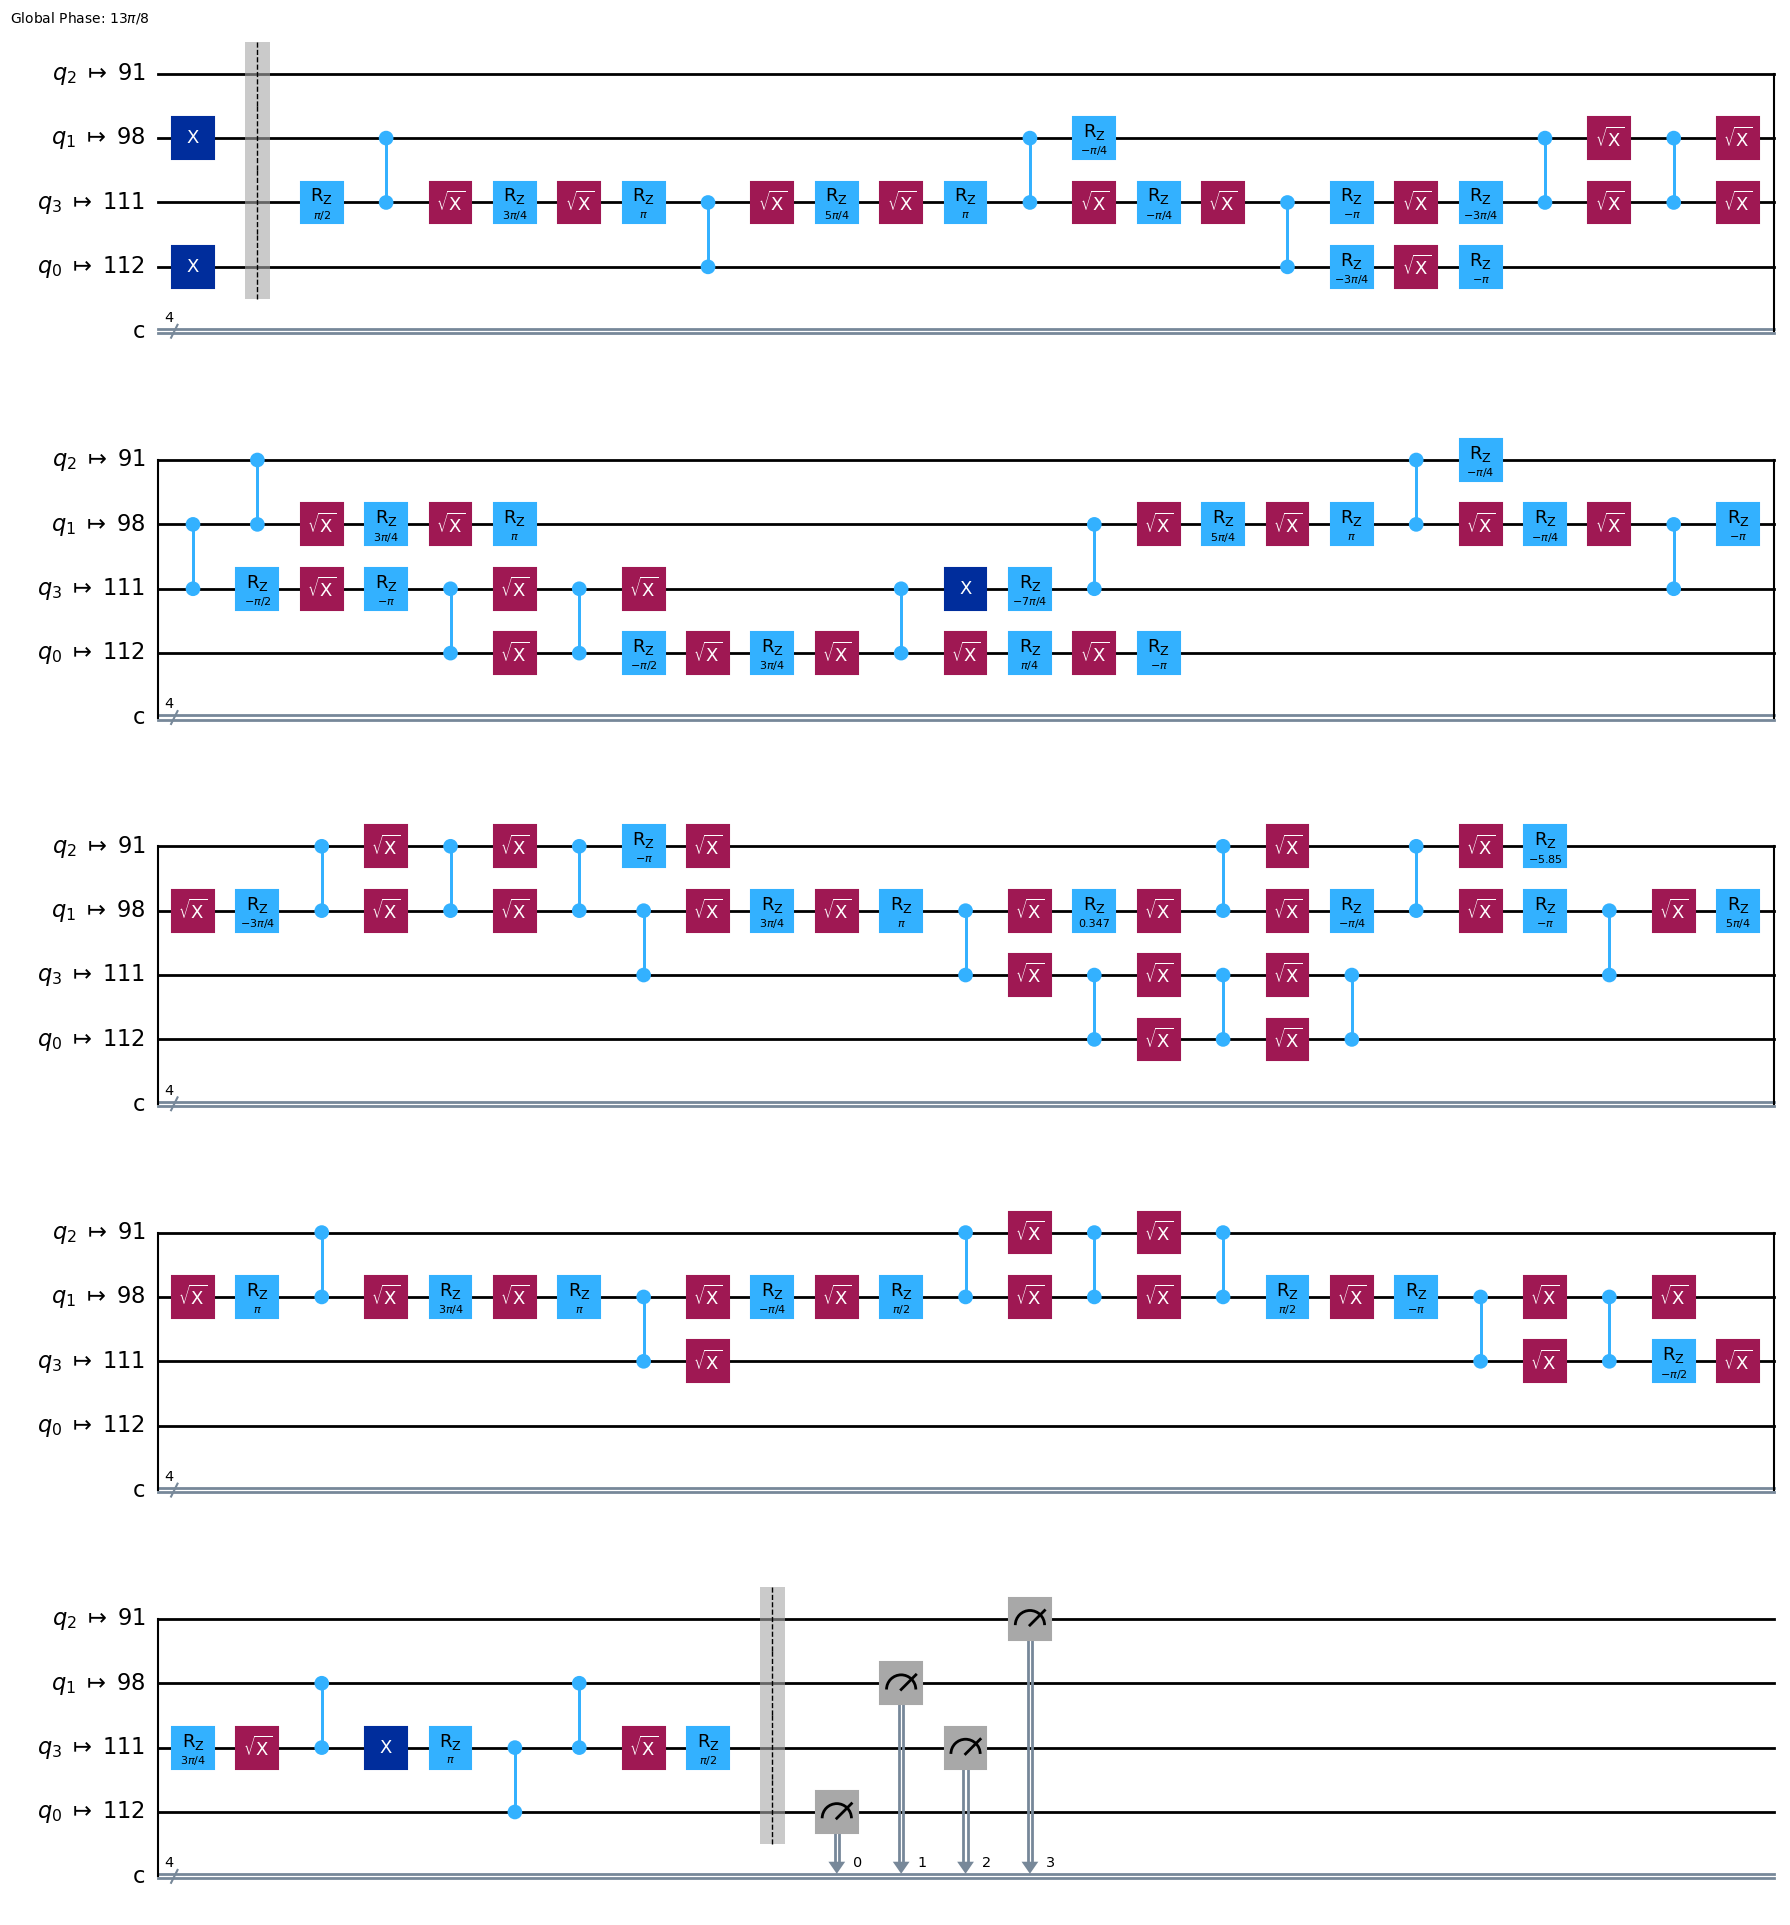

Job ID: d9b3ere6hjac73ff5mdg
Resultado real: {'1011': 841, '0011': 35, '1111': 19, '1101': 25, '1110': 27, '1001': 15, '1000': 6, '1010': 8, '0000': 3, '0010': 6, '0111': 7, '0110': 8, '0101': 14, '1100': 5, '0001': 2, '0100': 3}


In [8]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Carrega a conta já configurada
service = QiskitRuntimeService()

# Seleciona uma máquina real disponível
backend = service.least_busy(
    operational=True,
    simulator=False
)

print("Máquina selecionada:", backend.name)

# Escolha uma entrada
A = 1
B = 1
carry_in = 0

circuit = criar_somador(A, B, carry_in)

# Adapta o circuito à máquina escolhida
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuit = pass_manager.run(circuit)

display(isa_circuit.draw("mpl", idle_wires=False))

# Executa na máquina real
sampler = SamplerV2(mode=backend)

job = sampler.run(
    [isa_circuit],
    shots=1024
)

print("Job ID:", job.job_id())

result = job.result()
counts_real = result[0].data.c.get_counts()

print("Resultado real:", counts_real)

## Ex 3

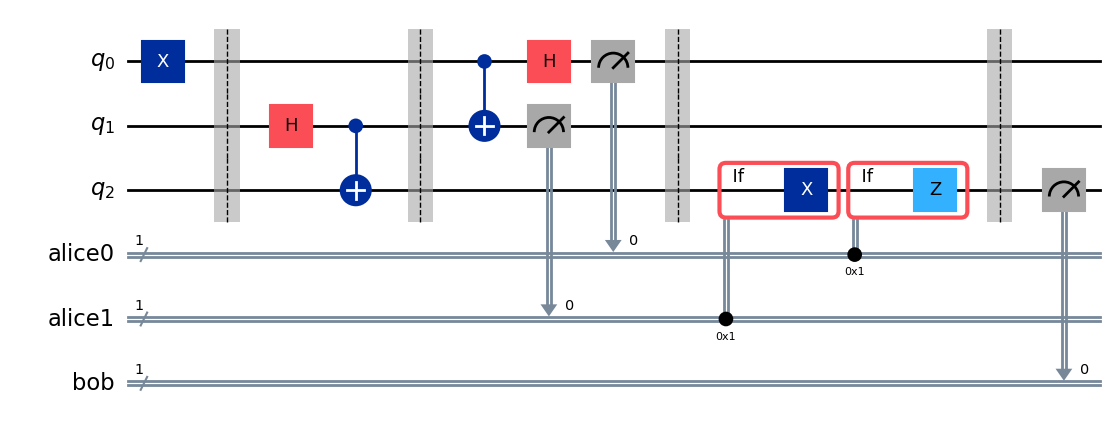

In [9]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Registradores quânticos
q = QuantumRegister(3, "q")

# Bits clássicos:
# alice0 recebe a medição de q0
# alice1 recebe a medição de q1
# bob recebe a medição final de q2
alice0 = ClassicalRegister(1, "alice0")
alice1 = ClassicalRegister(1, "alice1")
bob = ClassicalRegister(1, "bob")

circuit = QuantumCircuit(q, alice0, alice1, bob)

# -------------------------------------------------
# 1. Estado a ser teleportado: |1>
# -------------------------------------------------
circuit.x(q[0])
circuit.barrier()

# -------------------------------------------------
# 2. Criação do par de Bell entre q1 e q2
# -------------------------------------------------
circuit.h(q[1])
circuit.cx(q[1], q[2])
circuit.barrier()

# -------------------------------------------------
# 3. Operações realizadas por Alice
# -------------------------------------------------
circuit.cx(q[0], q[1])
circuit.h(q[0])

circuit.measure(q[0], alice0[0])
circuit.measure(q[1], alice1[0])
circuit.barrier()

# -------------------------------------------------
# 4. Correções realizadas por Bob
# -------------------------------------------------

# Se q1 foi medido como 1, aplica X em q2
with circuit.if_test((alice1, 1)):
    circuit.x(q[2])

# Se q0 foi medido como 1, aplica Z em q2
with circuit.if_test((alice0, 1)):
    circuit.z(q[2])

circuit.barrier()

# Medição final do qubit de Bob
circuit.measure(q[2], bob[0])

display(circuit.draw("mpl"))

Resultados: {'1 1 1': 252, '1 0 0': 291, '1 0 1': 232, '1 1 0': 249}


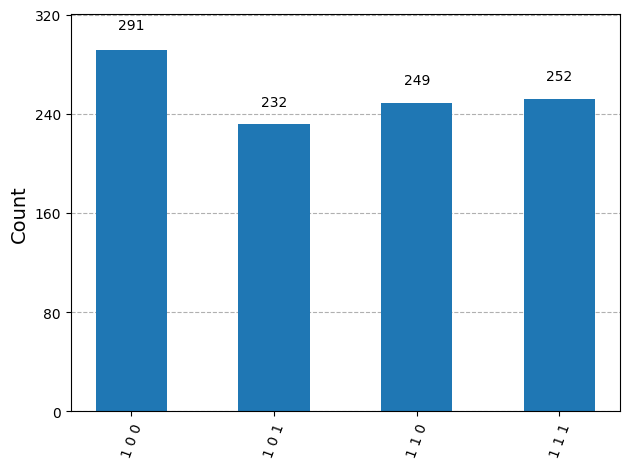

In [10]:
simulator = AerSimulator()

result = simulator.run(
    circuit,
    shots=1024
).result()

counts = result.get_counts()

print("Resultados:", counts)

plot_histogram(counts)

In [11]:
successful_shots = 0

for result_string, count in counts.items():
    bob_result = result_string.split()[0]

    if bob_result == "1":
        successful_shots += count

probability = successful_shots / 1024

print("Resultados corretos:", successful_shots)
print(f"Probabilidade de sucesso: {probability:.2%}")

Resultados corretos: 1024
Probabilidade de sucesso: 100.00%


## Ex 4

Mensagem enviada: 11


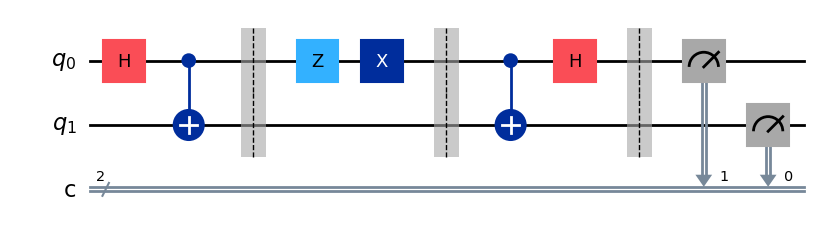

Contagens: {'11': 1024}
Probabilidade de receber 11: 100.00%


In [22]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt


def superdense_coding(message: str) -> QuantumCircuit:
    """
    Cria o circuito de codificação superdensa.

    message:
        '00', '01', '10' ou '11'
    """

    if message not in {"00", "01", "10", "11"}:
        raise ValueError("A mensagem deve ser 00, 01, 10 ou 11.")

    circuit = QuantumCircuit(2, 2)

    # ------------------------------------------------
    # 1. Criar o par de Bell compartilhado
    # ------------------------------------------------
    circuit.h(0)
    circuit.cx(0, 1)

    circuit.barrier()

    # ------------------------------------------------
    # 2. Alice codifica dois bits no qubit q[0]
    # ------------------------------------------------
    first_bit = message[0]
    second_bit = message[1]

    # Primeiro bit controla Z
    if first_bit == "1":
        circuit.z(0)

    # Segundo bit controla X
    if second_bit == "1":
        circuit.x(0)

    circuit.barrier()

    # ------------------------------------------------
    # 3. Bob decodifica a mensagem
    # ------------------------------------------------
    circuit.cx(0, 1)
    circuit.h(0)

    circuit.barrier()

    # Qiskit mostra os bits como c[1]c[0].
    # Para obter a mensagem na mesma ordem:
    circuit.measure(0, 1)
    circuit.measure(1, 0)

    return circuit


# Escolha a mensagem:
message = "11"

circuit = superdense_coding(message)

print("Mensagem enviada:", message)

# Mostra o circuito graficamente
display(circuit.draw("mpl"))
plt.show()

# Simulador local
simulator = AerSimulator()

compiled_circuit = transpile(
    circuit,
    simulator,
    optimization_level=1
)

job = simulator.run(
    compiled_circuit,
    shots=1024
)

result = job.result()
counts = result.get_counts()

print("Contagens:", counts)

expected_count = counts.get(message, 0)
probability = expected_count / 1024

print(f"Probabilidade de receber {message}: {probability:.2%}")


qiskit_runtime_service.__init__:WARNING:2026-07-15 14:53:17,240: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: teste. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-15 14:53:17,646: Loading instance: teste, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-15 14:53:20,737: Using instance: teste, plan: open


Máquina selecionada: ibm_kingston
Circuito original:


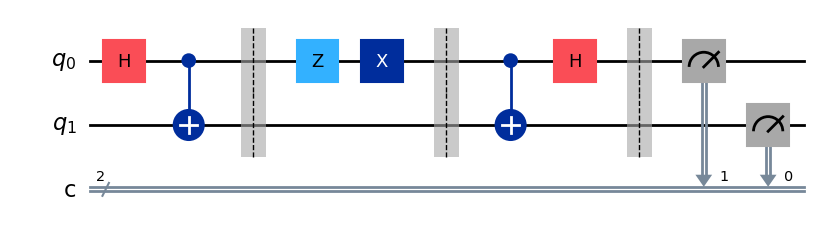

Circuito transpilado para a máquina:


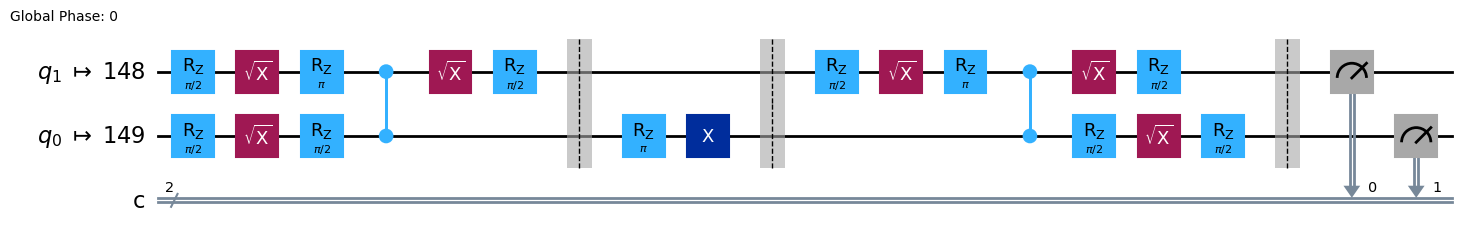

Job ID: d9bsi4m6hjac73fg61j0
Aguardando o resultado...
Resultado real: {'11': 1007, '01': 8, '10': 9}
Probabilidade de receber 11: 98.34%


In [24]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Mensagem escolhida
message = "11"

# Cria o circuito usando sua função
circuit = superdense_coding(message)

# Conecta à conta IBM Quantum já configurada
service = QiskitRuntimeService()

# Escolhe uma máquina real operacional
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=2
)

print("Máquina selecionada:", backend.name)

# Converte o circuito para as portas físicas da máquina
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuit = pass_manager.run(circuit)

print("Circuito original:")
display(circuit.draw("mpl"))

print("Circuito transpilado para a máquina:")
display(isa_circuit.draw("mpl", idle_wires=False))

# Executa na máquina real
sampler = SamplerV2(mode=backend)

job = sampler.run(
    [isa_circuit],
    shots=1024
)

print("Job ID:", job.job_id())
print("Aguardando o resultado...")

result_real = job.result()

# Como o registrador clássico padrão se chama "c"
counts_real = result_real[0].data.c.get_counts()

print("Resultado real:", counts_real)

correct_count = counts_real.get(message, 0)
probability_real = correct_count / 1024

print(
    f"Probabilidade de receber {message}: "
    f"{probability_real:.2%}"
)

plot_histogram(
    counts_real,
    title=f"Máquina real — mensagem {message}"
)

plt.show()

## Ex 5

In [ ]:
!pip install --quiet cirq

In [ ]:
import cirq
import numpy as np


def create_bell_test_circuit():
    """
    Cria uma rodada do jogo CHSH usado para testar
    a desigualdade de Bell.
    """

    # Qubits emaranhados de Alice e Bob
    alice = cirq.NamedQubit("Alice")
    bob = cirq.NamedQubit("Bob")

    # Qubits que representam as perguntas aleatórias x e y
    alice_referee = cirq.NamedQubit("Alice_referee")
    bob_referee = cirq.NamedQubit("Bob_referee")

    circuit = cirq.Circuit()

    # -------------------------------------------------
    # 1. Cria um par emaranhado entre Alice e Bob
    # -------------------------------------------------
    circuit.append(cirq.H(alice))
    circuit.append(cirq.CNOT(alice, bob))

    # -------------------------------------------------
    # 2. Gera perguntas aleatórias x e y
    # -------------------------------------------------
    circuit.append(cirq.H(alice_referee))
    circuit.append(cirq.H(bob_referee))

    circuit.append(
        cirq.measure(alice_referee, key="x")
    )
    circuit.append(
        cirq.measure(bob_referee, key="y")
    )

    # -------------------------------------------------
    # 3. Alice escolhe sua base de medição
    # -------------------------------------------------
    circuit.append(
        cirq.CNOT(alice_referee, alice)
    )

    # -------------------------------------------------
    # 4. Bob escolhe sua base de medição
    # -------------------------------------------------
    circuit.append(
        cirq.ry(-np.pi / 4).on(bob)
    )

    circuit.append(
        cirq.CNOT(bob_referee, bob)
    )

    circuit.append(
        cirq.ry(np.pi / 2).on(bob).controlled_by(bob_referee)
    )

    # -------------------------------------------------
    # 5. Mede as respostas de Alice e Bob
    # -------------------------------------------------
    circuit.append(cirq.measure(alice, key="a"))
    circuit.append(cirq.measure(bob, key="b"))

    return circuit